# K 近邻算法

K 近邻算法（K-Nearest Neighbors，简称 KNN）是一种简单且常用的分类和回归算法。

K 近邻算法属于监督学习的一种，核心思想是通过计算待分类样本与训练集中各个样本的距离，找到距离最近的 K 个样本，然后根据这 K 个样本的类别或值来预测待分类样本的类别或值。

## KNN的基本原理
KNN 算法的基本原理可以概括为以下几个步骤:
- 1. 计算距离 : 计算待分类样本与训练集中每个样本的距离。常用的距离度量方法有欧氏距离、曼哈顿距离等。
- 2. 选择 K 个最近邻：根据计算出的距离，选择距离最近的 K 个样本。
- 3. 投票或平均 : 对于分类问题 , K 个最近邻中出现次数最多的类别即为待分类样本的类别；对于回归问题，K 个最近邻的值的平均值即为待分类样本的值。

## KNN的特点
- 简单易理解 : KNN 算法的原理非常简单，容易理解和实现
- 无需训练 : KNN 是一种懒惰学习的算法，不需要在训练阶段进行模型的构建，直接使用训练数据进行预测。
- 对数据分布无假设 : KNN 不对数据的分布做任何假设，适用于各种类型的数据。
- 计算复杂度高 : KNN 在预测阶段需要计算待分类样本与训练集中每个样本的距离，计算复杂度较高，尤其是当训练集较大时。

## KNN的优缺点
### 优点
- 简单易实现 : KNN 算法的实现非常简单，适合初学者学习和理解。
- 适用于多分类问题 : KNN 可以处理多分类问题，不需要对数据进行特殊处理。
- 无需训练 : KNN 不需要在训练阶段进行模型的构建，直接使用训练数据进行预测。

### 缺点
- 计算复杂度高 : KNN 在预测阶段需要计算待分类样本与训练集中每个样本的距离，计算复杂度较高，尤其是当训练集较大时。
- 对噪声敏感 : KNN 对于训练数据中的噪声和异常值较为敏感，可能会影响预测的准确性。
- 需要选择合适的 K 值 : KNN 的性能很大程度上取决于 K 值的选择，过小的 K 值可能会导致过拟合，而过大的 K 值可能会导致欠拟合。

-----

In [16]:
# 1. 导入必要的库
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [17]:
# 2. 加载数据
# 加载Iris数据集
iris = load_iris()
X = iris.data[:, :2]  # 只取前两个特征，便于可视化
y = iris.target

In [18]:
# 3. 数据预处理
# 在应用 KNN 算法之前，通常需要对数据进行标准化处理，以确保每个特征对距离计算的贡献是相同的。
# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
# 4. 训练K近邻模型
# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [20]:
# 5. 模型评估
# 使用测试集进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN模型的准确率: {accuracy:.2f}')

KNN模型的准确率: 0.76


KNN模型的准确率: 0.7556


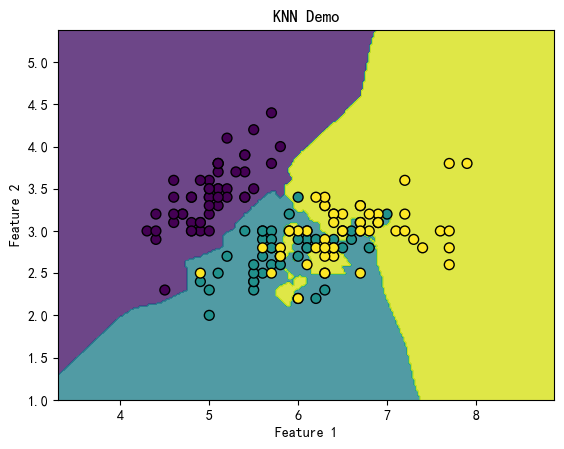

In [21]:
# 可视化
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征，便于可视化
y = iris.target

# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN模型的准确率: {accuracy:.4f}")

# 绘制决策边界和数据点
h = .02  # 网格步长
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 创建一个二维网格，表示不同的样本空间
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 使用KNN模型预测网格中的每个点的类别
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.8)

# 绘制训练数据点
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50)
plt.title("KNN Demo")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

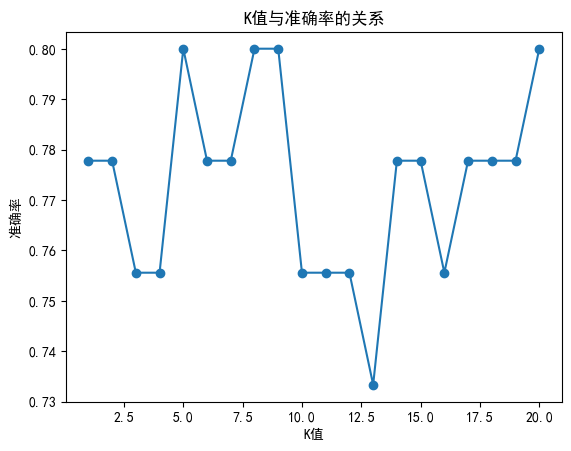

In [22]:
# 7. 调整K值
# 选择不同的K值进行训练和评估
# 尝试不同的K值并绘制准确率变化
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# 设置中文字体
plt.rcParams['font.sans-serif'] = [
    # windows
    'SimHei', 'Microsoft YaHei'
]

# 修复负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False


# 绘制K值与准确率的关系
plt.plot(k_range, accuracies, marker='o')
plt.title("K值与准确率的关系")
plt.xlabel("K值")
plt.ylabel("准确率")
plt.show()


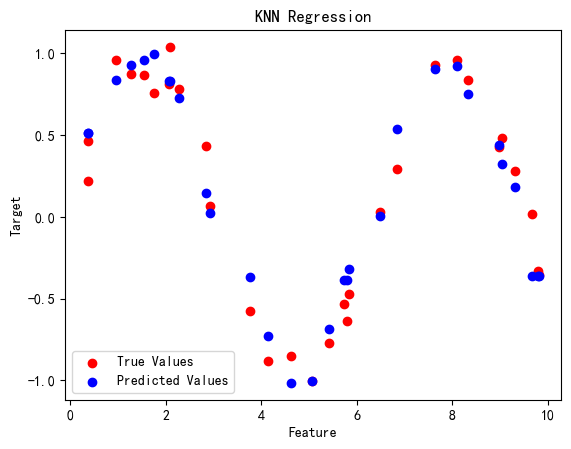

In [23]:
# 8. 使用 KNN 进行回归任务

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# 生成示例数据
X = np.random.rand(100, 1) * 10
y = np.sin(X).ravel() + 0.1 * np.random.randn(100)

# 拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN回归模型
knn_reg = KNeighborsRegressor(n_neighbors=5)

# 训练模型
knn_reg.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn_reg.predict(X_test)

# 可视化回归结果
plt.scatter(X_test, y_test, color='red', label='True Values')
plt.scatter(X_test, y_pred, color='blue', label='Predicted Values')
plt.title("KNN Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()
